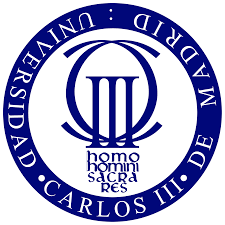

# **PRACTICA 03 - APLICACIONES AVANZADAS DE LA IA - IA EN LA EMPRESA**
---
**GRUPO 10**
*   Sergio Caño Amor (100429678)
*   Eduardo Enrique Angulo Luna (100545176)
*   Pablo Hidalgo Delgado (100451225)


## **1. Introducción**
El objetivo de esta práctica es analizar temas en documentos de noticias en inglés utilizando dos enfoques distintos: un modelo supervisado de clasificación de temas y un modelo no supervisado de modelado de temas.

- Para completar la primera tarea, entrenaremos un clasificador multiclase que será capaz de predecir la categoría a la que pertenece un documento, utilizando datos previamente etiquetados en cinco temas distintos. Para evaluar el rendimiento del modelo, emplearemos validación cruzada y lo evaluaremos con el conjunto de test.

- En la segunda tarea, aplicaremos técnicas de clustering, ignorando las etiquetas. El objetivo es identificar los principales temas tratados en los documentos, agrupándolos en clústeres según su contenido. Para ello, construiremos un modelo K-Means utilizando embeddings estáticos, aunque exploraremos otras opciones.


## **2. Lectura de los datos.**

En primer lugar, importamos las librerías que necesitaremos a lo largo del proyecto:

In [2]:
# Cada vez que no funcione, hay que correr esta celda, saldrá un mensaje de que hay que reiniciar el entorno de ejecucion
# al que hay que dar que si. Despues correr la celda de abajo (la de los imports)
!pip uninstall -y numpy scipy gensim jax jaxlib cvxpy scikit-image
!pip install --no-cache-dir numpy==1.23.5 scipy==1.11.4 gensim==4.3.3
!pip install -U sentence-transformers bertopic hdbscan

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.14.1
Uninstalling scipy-1.14.1:
  Successfully uninstalled scipy-1.14.1
Found existing installation: jax 0.5.2
Uninstalling jax-0.5.2:
  Successfully uninstalled jax-0.5.2
Found existing installation: jaxlib 0.5.1
Uninstalling jaxlib-0.5.1:
  Successfully uninstalled jaxlib-0.5.1
Found existing installation: cvxpy 1.6.4
Uninstalling cvxpy-1.6.4:
  Successfully uninstalled cvxpy-1.6.4
Found existing installation: scikit-image 0.25.2
Uninstalling scikit-image-0.25.2:
  Successfully uninstalled scikit-image-0.25.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 227.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 137.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 138.6 MB/s eta 0:00:00
ERROR: pip's depend

ERROR: Operation cancelled by user
^C


In [1]:
# LIBRERÍAS UTILIZADAS

#!pip uninstall -y numpy gensim
#!pip install --no-cache-dir numpy gensim




import numpy as np
import gensim
from gensim.models import Word2Vec
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import hdbscan
from sentence_transformers import SentenceTransformer
from sklearn.metrics import silhouette_score
from nltk.tokenize import word_tokenize


# RECURSOS DE NLTK
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

A continuación, descomprimimos el archivo `ZIP` y leemos los textos de cada categoría. Cada categoría se guarda en un dataframe dentro de un diccionario para acceder fácilmente a los datos.

In [2]:
# Función para descomprimir archivos ZIP
def unzip_file(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Descomprimir archivos ZIP de entrenamiento y prueba
unzip_file('bbc-train.zip', './')
unzip_file('bbc-test.zip', './')

# Categorías disponibles
categories = ['business', 'entertainment', 'politics', 'sports', 'tech']

# Función para cargar archivos .txt desde una carpeta y guardarlos en un DataFrame
def load_texts_from_folder(base_path, categories):
    dataframes = {}
    for category in categories:
        folder_path = os.path.join(base_path, category)
        texts = [
            open(os.path.join(folder_path, file_name), 'r', encoding='latin-1').read()
            for file_name in os.listdir(folder_path)
        ]
        dataframes[category] = pd.DataFrame({'text': texts})
    return dataframes

# Cargar textos de train y test
dataframes_train = load_texts_from_folder('bbc-train', categories)
dataframes_test = load_texts_from_folder('bbc-test', categories)

Cada DataFrame contiene una única columna llamada text, donde cada fila representa el contenido de un archivo .txt de la categoría correspondiente.

Para entrenar nuestro modelo, combinaremos todos los textos en un único DataFrame. Además, agregaremos una columna con la etiqueta de cada documento, representando su categoría con un número:

In [3]:
# Asignación de etiquetas numéricas a cada categoría
category_map = {category: idx for idx, category in enumerate(categories)}

# Agregar columna 'type' con la etiqueta correspondiente
for category, df in dataframes_train.items():
    df['type'] = category_map[category]

print("Numero de columnas: ", dataframes_train["sports"].shape[1])
print(dataframes_train["sports"].head())

Numero de columnas:  2
                                                text  type
0  Fit-again Betsen in France squad\n\nFrance hav...     3
1  Moya emotional at Davis Cup win\n\nCarlos Moya...     3
2  Melzer shocks Agassi\n\nSecond seed Andre Agas...     3
3  Smith keen on Home series return\n\nScotland m...     3
4  Juninho demand for O'Neill talks\n\nJuninho's ...     3


In [4]:
df_train = pd.concat([dataframes_train["business"], dataframes_train["entertainment"], dataframes_train["politics"], dataframes_train["sports"], dataframes_train["tech"]], ignore_index=True)
print(df_train)

                                                   text  type
0     Retail sales show festive fervour\n\nUK retail...     0
1     Saudi investor picks up the Savoy\n\nLondon's ...     0
2     Chinese exports rise 25% in 2004\n\nExports fr...     0
3     GM, Ford cut output as sales fall\n\nUS car fi...     0
4     UK 'risks breaking golden rule'\n\nThe UK gove...     0
...                                                 ...   ...
2010  Bad e-mail habits sustains spam\n\nThe 'bad be...     4
2011  Microsoft debuts security tools\n\nMicrosoft i...     4
2012  'Brainwave' cap controls computer\n\nA team of...     4
2013  Apple attacked over sources row\n\nCivil liber...     4
2014  Robots learn 'robotiquette' rules\n\nRobots ar...     4

[2015 rows x 2 columns]


Realizamos lo propio para los datos de test:

In [5]:
# Asignación de etiquetas numéricas a cada categoría
category_map = {category: idx for idx, category in enumerate(categories)}

# Agregar columna 'type' con la etiqueta correspondiente
for category, df in dataframes_test.items():
    df['type'] = category_map[category]

print("Numero de columnas: ", dataframes_test["sports"].shape[1])
print(dataframes_test["sports"].head())

Numero de columnas:  2
                                                text  type
0  Minister digs in over doping row\n\nThe Belgia...     3
1  Rusedski forced out in Marseille\n\nGreg Rused...     3
2  Gardener battles to narrow win\n\nJason Garden...     3
3  Slovakia reach Hopman Cup final\n\nSlovakia wi...     3
4  London hope over Chepkemei\n\nLondon Marathon ...     3


In [6]:
df_test = pd.concat([dataframes_test["business"], dataframes_test["entertainment"], dataframes_test["politics"], dataframes_test["sports"], dataframes_test["tech"]], ignore_index=True)
print(df_test)

                                                  text  type
0    UK Coal plunges into deeper loss\n\nShares in ...     0
1    Electrolux to export Europe jobs\n\nElectrolux...     0
2    Japanese mogul arrested for fraud\n\nOne of Ja...     0
3    Hyundai to build new India plant\n\nSouth Kore...     0
4    Boeing unveils new 777 aircraft\n\nUS aircraft...     0
..                                                 ...   ...
205  Digital guru floats sub-$100 PC\n\nNicholas Ne...     4
206  Global blogger action day called\n\nThe global...     4
207  UK net users leading TV downloads\n\nBritish T...     4
208  Looks and music to drive mobiles\n\nMobile pho...     4
209  What high-definition will do to DVDs\n\nFirst ...     4

[210 rows x 2 columns]


## **3. Análisis exploratorio de los datos.**
Antes de comenzar con la fase de preprocesamiento, vamos a realizar un análisis exploratorio de datos (`EDA`). De esta manera, podremos investigar y resumir las características más importantes de nuestro conjunto de datos. Esto nos servirá para comprender mejor los datos y optimizar la obtención de nuestro modelo.

### **3.1. Información básica.**

Primero, revelaremos la información basica sobre los datos que hemos obtenido.

In [ ]:
# Mostrar información básica de los datos de entrenamiento y prueba
print("=== INFORMACIÓN BÁSICA DE LOS DATOS ===\n")

for category in categories:
    train_size = dataframes_train[category].shape[0]
    test_size = dataframes_test[category].shape[0]
    num_columns = dataframes_train[category].shape[1]

    print(f"📌 **Categoría:** {category.upper()}")
    print(f"   🔹 Textos en TRAIN: {train_size}")
    print(f"   🔹 Textos en TEST: {test_size}")
    print(f"   🔹 Columnas en TRAIN: {num_columns}\n")

    # Mostrar un ejemplo de texto para la categoría
    print(f"🔍 **Ejemplo de texto en {category}:**\n")
    print(dataframes_train[category]['text'].iloc[0][:300], "...")  # Muestra los primeros 300 caracteres

    print("\n")

    print(f"🔍 **Ejemplo de filas en {category}:**\n")
    print(dataframes_train[category]['text'].head(), "...")

    print("-" * 80, "\n")  # Separador entre categorías

=== INFORMACIÓN BÁSICA DE LOS DATOS ===

📌 **Categoría:** BUSINESS
   🔹 Textos en TRAIN: 460
   🔹 Textos en TEST: 50
   🔹 Columnas en TRAIN: 2

🔍 **Ejemplo de texto en business:**

Ban on forced retirement under 65

Employers will no longer be able to force workers to retire before 65, unless they can justify it.

The government has announced that firms will be barred from 2006 from imposing arbitrary retirement ages. Under new European age discrimination rules, a default reti ...


🔍 **Ejemplo de filas en business:**

0    Ban on forced retirement under 65\n\nEmployers...
1    VW considers opening Indian plant\n\nVolkswage...
2    Enron bosses in $168m payout\n\nEighteen forme...
3    Bank set to leave rates on hold\n\nUK interest...
4    US Airways staff agree to pay cut\n\nA union r...
Name: text, dtype: object ...
-------------------------------------------------------------------------------- 

📌 **Categoría:** ENTERTAINMENT
   🔹 Textos en TRAIN: 356
   🔹 Textos en TEST: 30
   🔹 C

### **3.2. Distribución de textos por clase.**

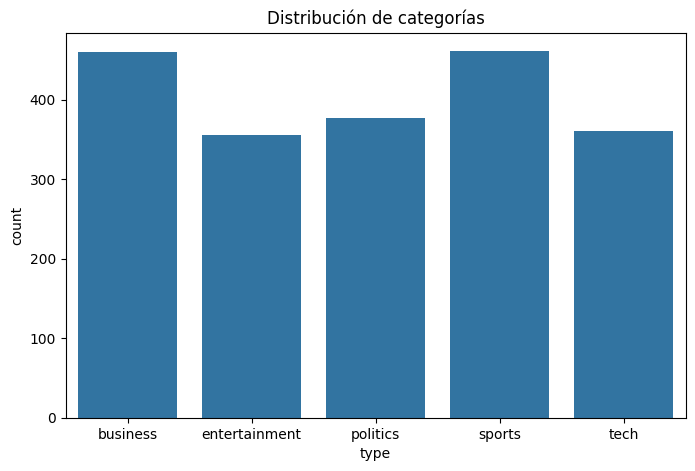

Cantidad de textos por categoría:
3: 461
0: 460
2: 377
4: 361
1: 356


In [ ]:
# Gráfico de barras
plt.figure(figsize=(8,5))
sns.countplot(x=df_train['type'])

# Cambiar los nombres de las categorías en el eje x
plt.xticks(ticks=range(len(categories)), labels=categories)

# Título del gráfico
plt.title("Distribución de categorías")
plt.show()

# Contar textos por categoría
category_counts = df_train['type'].value_counts()

# Imprimimos valores de cada categoría
print("Cantidad de textos por categoría:")
for category, count in category_counts.items():
    print(f"{category}: {count}")


Vemos que estamos ante un problema **balanceado**, ya que no hay ninguna categoría que contenga un número significativamente menor de textos que otra.

### **3.3. Distribución de longitud de textos y número de palabras por categoría.**

A continuación, identificaremos diferencias en la longitud de los textos, es decir, las palabras que contienen por categoría.

<ipython-input-7-e45421748abf>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="text_length", palette="coolwarm")


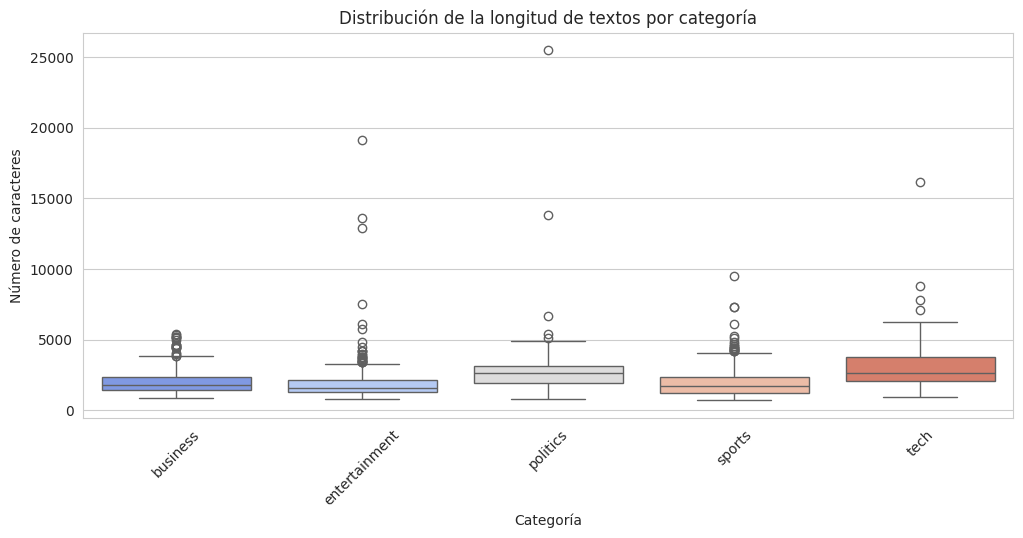

<ipython-input-7-e45421748abf>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="category", y="word_count", palette="magma")


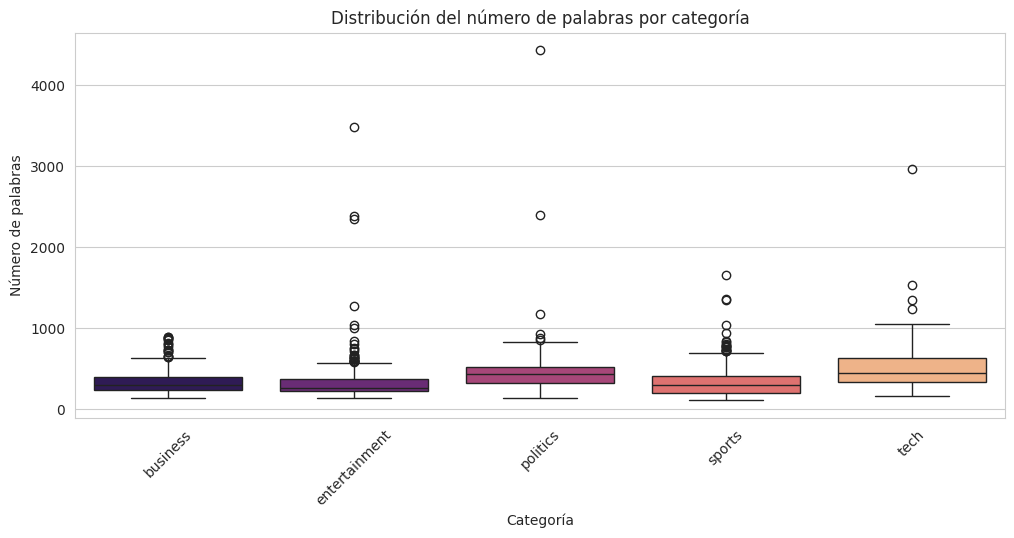

              text_length                                                     \
                    count     mean      std    min      25%     50%      75%   
category                                                                       
business            460.0  2003.88   838.05  849.0  1413.00  1823.0  2386.25   
entertainment       356.0  1960.84  1511.43  825.0  1317.75  1574.0  2130.50   
politics            377.0  2647.75  1567.10  812.0  1919.00  2604.0  3121.00   
sports              461.0  1912.23  1041.66  721.0  1212.00  1691.0  2364.00   
tech                361.0  2985.33  1391.90  975.0  2047.00  2638.0  3791.00   

                       word_count                                        \
                   max      count    mean     std    min     25%    50%   
category                                                                  
business        5410.0      460.0  331.52  139.42  140.0  232.75  299.0   
entertainment  19138.0      356.0  336.44  270.80  145.0  2

In [ ]:
category_mapping = {
    0: 'business',
    1: 'entertainment',
    2: 'politics',
    3: 'sports',
    4: 'tech'
}

# Creamos un DataFrame con la longitud del texto y el número de palabras
df = pd.DataFrame()
df['category'] = df_train['type'].map(category_mapping)
df['text_length'] = df_train["text"].apply(len)
df['word_count'] = df_train["text"].apply(lambda x: len(x.split()))

# Configuración de estilo
sns.set_style("whitegrid")

# Gráfico de la distribución de la longitud de los textos por categoría
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="category", y="text_length", palette="coolwarm")
plt.title("Distribución de la longitud de textos por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de caracteres")
plt.xticks(rotation=45)
plt.show()

# Gráfico de la distribución del número de palabras por categoría
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x="category", y="word_count", palette="magma")
plt.title("Distribución del número de palabras por categoría")
plt.xlabel("Categoría")
plt.ylabel("Número de palabras")
plt.xticks(rotation=45)
plt.show()

# Tabla resumen
summary = df.groupby("category")[["text_length", "word_count"]].describe().round(2)
print(summary)

Observamos que algunas categorías, como `tech` y `politics`, tienden a tener textos más **largos**, mientras que `sports` y `entertainment` presentan textos más **concisos**. Además, identificamos una gran variabilidad en la longitud de los textos, con la presencia de valores atípicos (outliers).

### **3.4. Word Cloud.**

Crearemos un Word Cloud para ver las palabras que mas se repiten en los distintos tipos de texto. Como podemos observar, las palabras que mas se repiten suelen tener mucho que ver con el tipo de texto en el que estan clasificados.

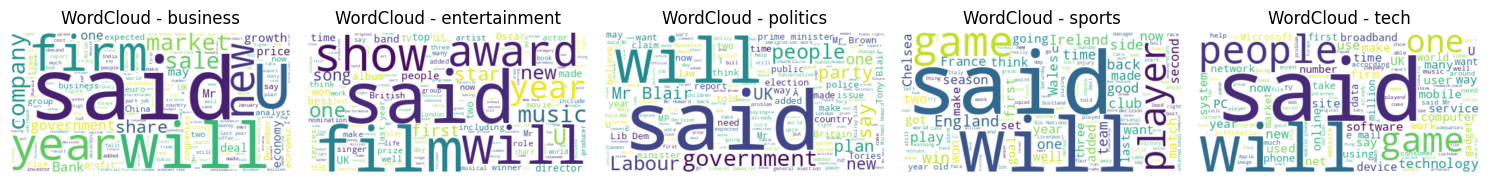

In [ ]:
# Crear una lista de categorías
categories = df_train['type'].unique()

# Crear la figura con subgráficos (una fila, tantas columnas como categorías)
fig, axes = plt.subplots(1, len(categories), figsize=(15, 5))

# Generar y mostrar la nube de palabras para cada categoría
for i, category in enumerate(categories):
    text = " ".join(df_train[df_train['type'] == category]['text'])
    wordcloud = WordCloud(width=400, height=200, background_color='white').generate(text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"WordCloud - {category_mapping[category]}")
    axes[i].axis("off")

# Ajustar el espacio entre las gráficas
plt.tight_layout()
plt.show()

### **3.5 Análisis de Palabras Más Distintivas por Clase**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Tomamos una muestra de datos para cada categoría
texts = []
labels = []
for category in categories:
    texts.extend(dataframes_train[category]['text'])
    labels.extend([category] * len(dataframes_train[category]))

# Aplicamos TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
X_tfidf = vectorizer.fit_transform(texts)

# Obtener las palabras más relevantes por categoría
feature_names = np.array(vectorizer.get_feature_names_out())

# Calcular la media de los valores TF-IDF por categoría
category_means = {}
for i, category in enumerate(categories):
    category_means[category] = np.mean(X_tfidf[np.array(labels) == category].toarray(), axis=0)

# Mostrar las palabras más distintivas de cada categoría
for category in categories:
    sorted_indices = np.argsort(category_means[category])[::-1][:10]  # Top 10 palabras
    print(f"🔹 **Palabras más distintivas en {category.upper()}:**")
    print(", ".join(feature_names[sorted_indices]), "\n")


🔹 **Palabras más distintivas en BUSINESS:**
said, company, market, mr, firm, bank, growth, year, shares, economy 

🔹 **Palabras más distintivas en ENTERTAINMENT:**
film, best, said, music, awards, award, band, tv, star, year 

🔹 **Palabras más distintivas en POLITICS:**
mr, said, labour, blair, government, party, election, minister, people, brown 

🔹 **Palabras más distintivas en SPORTS:**
game, england, said, win, cup, team, match, club, players, injury 

🔹 **Palabras más distintivas en TECH:**
people, said, technology, mobile, software, users, computer, games, digital, net 



### **3.6 Análisis de Bigramas**

In [ ]:
from collections import Counter
from nltk.util import ngrams
import nltk

def get_top_ngrams(texts, n=2, top_k=10):
    all_ngrams = []
    for text in texts:
        tokens = nltk.word_tokenize(text.lower())  # Tokenizar
        all_ngrams.extend(list(ngrams(tokens, n)))  # Obtener n-gramas

    # Contar frecuencia de n-gramas
    ngram_counts = Counter(all_ngrams)

    return ngram_counts.most_common(top_k)

# Mostrar los bigramas más comunes por categoría
for category in categories:
    print(f"🔹 **Bigrams más comunes en {category.upper()}:**")
    print(get_top_ngrams(dataframes_train[category]['text'], n=2), "\n")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


🔹 **Bigrams más comunes en BUSINESS:**
[(('.', 'the'), 1200), (('in', 'the'), 925), (('of', 'the'), 914), (('.', '``'), 866), ((',', 'the'), 650), ((',', "''"), 601), (('for', 'the'), 362), (('the', 'us'), 359), (('to', 'the'), 355), (('said', '.'), 311)] 

🔹 **Bigrams más comunes en ENTERTAINMENT:**
[(('.', 'the'), 866), (('of', 'the'), 837), (('in', 'the'), 762), (('.', '``'), 746), ((',', "''"), 421), (('.', "''"), 355), (('at', 'the'), 342), ((',', 'the'), 275), (('for', 'the'), 274), ((',', 'which'), 258)] 

🔹 **Bigrams más comunes en POLITICS:**
[(('.', '``'), 1121), (('.', 'the'), 962), (('of', 'the'), 944), (('in', 'the'), 790), (('.', "''"), 772), ((':', '``'), 564), (('to', 'the'), 511), (("''", '.'), 482), (('.', 'he'), 468), (('he', 'said'), 455)] 

🔹 **Bigrams más comunes en SPORTS:**
[(('.', '``'), 2104), (('in', 'the'), 1157), (('.', "''"), 917), (('of', 'the'), 716), ((',', "''"), 642), (('.', 'the'), 567), (('``', 'i'), 564), ((')', ','), 463), (('for', 'the'), 422), (

Se observa que los bigramas más frecuentes en cada categoría están compuestos, en su mayoría, por palabras sin un significado semántico relevante, como artículos, preposiciones y signos de puntuación. Esto nos indica la necesidad de eliminar este tipo de términos mediante la **eliminación de stopwords** y **signos de puntuación**, con el fin de obtener patrones más representativos del contenido de los textos.

## **4. Modelo Supervisado**

### **4.1 Preprocesamiento de los datos.**
El preprocesamiento de los datos es fundamental a la hora de analizar y clasificar textos. Los datos actuales se encuentran como textos en bruto, con elementos que pueden dificultar el rendimiento de los modelos de machine learning, como puntuación innecesaria, mayúsculas, palabras irrelevantes o variaciones morfológicas de una misma palabra.

El objetivo principal del preprocesamiento es transformar el texto en un formato limpio, uniforme y más manejable para que el modelo pueda enfocarse en las características realmente importantes. Esto ayuda a reducir el ruido, mejora la calidad de las representaciones vectoriales y, en consecuencia, incrementa la precisión del modelo de clasificación.

#### **4.1.1 Aleatorización de los datos**

In [ ]:
# Aleatorizar los datos de entrenamiento y prueba
df_train = shuffle(df_train, random_state=42)
df_test = shuffle(df_test, random_state=42)

#### **4.1.2 Limpiar y normalizar el texto**
Una vez que tenemos los textos organizados y etiquetados, el siguiente paso clave es limpiar y normalizar el texto. Este proceso permite transformar los datos en una forma más uniforme y adecuada para que los algoritmos de clasificación puedan enfocarse en patrones significativos y no en variaciones irrelevantes.

Las transformaciones que realizamos son las siguientes las siguientes:

1. **Conversión a minúsculas**:
Todo el texto se transforma a minúsculas para evitar que el modelo trate como palabras diferentes aquellas que solo difieren por su uso de mayúsculas. Por ejemplo, "Technology" y "technology" deben considerarse la misma palabra.

2. **Eliminación de signos de puntuación**:
Se eliminan los signos de puntuación y caracteres especiales, ya que no aportan significado semántico y pueden agregar ruido al conjunto de datos.

3. **Eliminación de números**:
Los números no son relevantes en este caso, por lo que se eliminan para evitar que el modelo los utilice como características.

4. **Eliminación de stopwords en inglés**:
Las stopwords son palabras muy comunes (como "the", "is", "and") que aparecen frecuentemente pero no contribuyen al contenido relevante del texto. Eliminarlas permite reducir el ruido y centrar el análisis en palabras clave.

5. **Lematización**:
La lematización convierte cada palabra a su forma base o raíz gramatical. Por ejemplo, palabras como running, ran o runs se reducen a run. Esto reduce la variabilidad y mejora la capacidad del modelo para generalizar.

In [ ]:
# Inicializar lematizador y stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar signos de puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Eliminar números
    text = " ".join([word for word in text.split() if not word.isdigit()])
    # Eliminar stopwords y lematizar
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text

print("Texto original:")
print(df_train.loc[0, 'text'][:100], "...")
# Aplicar preprocesamiento a los textos
df_train['text'] = df_train['text'].apply(preprocess_text)
df_test['text'] = df_test['text'].apply(preprocess_text)
print("\nTexto después de ser procesado:")
print(df_train.loc[0, 'text'][:100], "...")

Texto original:
Ban on forced retirement under 65

Employers will no longer be able to force workers to retire befor ...

Texto después de ser procesado:
ban forced retirement employer longer able force worker retire unless justify government announced f ...


#### **4.1.3 Vectorizar los textos**
Después de haber limpiado y normalzado los textos, los convertimos en una representación numérica que pueda ser utilizada por los algoritmos de aprendizaje automático. En este caso, utilizamos el enfoque de **Bag of Words** (BoW).

El modelo Bag of Words representa cada documento como un vector de frecuencias de palabras, donde cada dimensión del vector corresponde a una palabra en el vocabulario del conjunto de datos, y su valor es la cantidad de veces que esa palabra aparece en el documento. Este enfoque es simple pero efectivo, ya que convierte el texto en una forma estructurada que los modelos pueden procesar.

Para llevar a cabo esta vectorización, utilizamos el CountVectorizer de la librería scikit-learn. Este vectorizador realiza la tokenización implícita, es decir, automáticamente divide el texto en palabras o tokens, y calcula la frecuencia de cada token en el corpus. A continuación, se realiza la vectorización del conjunto de datos de entrenamiento y de prueba.

In [ ]:
# Inicializar el vectorizador BoW
vectorizer = CountVectorizer()

# Ajustar y transformar los datos de texto
df_train_vect = vectorizer.fit_transform(df_train['text'])
df_test_vect = vectorizer.transform(df_test['text'])


# Revisar la forma de la matriz BoW
print(df_train_vect.shape)  # Número de documentos x Número de términos en el vocabulario


(2015, 28353)


### **4.2. Entrenamiento.**


Hay diferentes tecnicas a elegir dentro de la clasificacion de textos con aprendizaje supervisado. En nuestro caso, empezaremos primero por: Naive Bayes con TF-IDF. La cual es una simple y eficaz solución, perfecta para empezar.

In [ ]:
X_train = df_train_vect
y_train = df_train['type']

# Definir el modelo
model = MultinomialNB()

# Definir los hiperparámetros a buscar
param_grid = {
    'alpha': [0.1, 0.5, 1.0, 5.0, 10.0],  # Diferentes valores de suavizado
    'fit_prior': [True, False]  # Si debe aprender los priors de los datos o asumir uniformes
}

# Definir las métricas que quieres usar
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Inicializar GridSearchCV con validación cruzada de 5 folds y múltiples métricas
grid_search = GridSearchCV(model, param_grid, cv=5, scoring=scoring_metrics, n_jobs=-1, refit='accuracy')

# Ajustar el modelo con los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Obtener los resultados de la búsqueda
results = pd.DataFrame(grid_search.cv_results_)

# Seleccionar las columnas relevantes
results = results[['param_alpha', 'param_fit_prior', 'mean_test_accuracy', 'mean_test_precision_macro', 'mean_test_recall_macro', 'mean_test_f1_macro', 'std_test_accuracy', 'std_test_precision_macro', 'std_test_recall_macro', 'std_test_f1_macro', 'rank_test_accuracy']]

# Ordenar por el mejor rendimiento (en este caso, basado en accuracy)
results = results.sort_values(by='mean_test_accuracy', ascending=False)

results = results.round(5)


# Mostrar los mejores parámetros encontrados
print("\nMejores hiperparámetros:", grid_search.best_params_)
print("Mejor Accuracy obtenido:", grid_search.best_score_)

# Guardar los resultados en un CSV
results.to_csv('grid_search_results_with_metrics.csv', index=False)

# Mostrar la tabla
pd.DataFrame(results)


Mejores hiperparámetros: {'alpha': 0.1, 'fit_prior': True}
Mejor Accuracy obtenido: 0.973697270471464


,param_alpha,param_fit_prior,mean_test_accuracy,mean_test_precision_macro,mean_test_recall_macro,mean_test_f1_macro,std_test_accuracy,std_test_precision_macro,std_test_recall_macro,std_test_f1_macro,rank_test_accuracy
0,0.1,True,0.97370,0.97260,0.97367,0.97285,0.00535,0.00581,0.00529,0.00555,1
1,0.1,False,0.97370,0.97260,0.97367,0.97285,0.00535,0.00581,0.00529,0.00555,1
2,0.5,True,0.97370,0.97274,0.97359,0.97287,0.00557,0.00568,0.00559,0.00565,1
3,0.5,False,0.97370,0.97274,0.97359,0.97287,0.00557,0.00568,0.00559,0.00565,1
4,1.0,True,0.97122,0.97041,0.97074,0.97015,0.00460,0.00469,0.00444,0.00462,5
5,1.0,False,0.97122,0.97041,0.97074,0.97015,0.00460,0.00469,0.00444,0.00462,5
6,5.0,True,0.96328,0.96295,0.96237,0.96152,0.00427,0.00386,0.00533,0.00525,7
7,5.0,False,0.96328,0.96295,0.96237,0.96152,0.00427,0.00386,0.00533,0.00525,7
9,10.0,False,0.95831,0.95854,0.95683,0.95583,0.00655,0.00559,0.00756,0.00764,9
8,10.0,True,0.95732,0.95762,0.95573,0.95479,0.00574,0.00485,0.00677,0.00687,10


### **4.3 Evaluación sobre el conjunto de test.**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
X_test = df_test_vect
y_test = df_test["type"]

# Entrenar el modelo con los mejores hiperparámetros
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

# Hacer predicciones en el conjunto de test
y_pred = best_model.predict(X_test)

# Evaluar el modelo
print("Accuracy en test:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Accuracy en test: 0.9904761904761905

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           1       1.00      0.97      0.98        30
           2       0.98      1.00      0.99        40
           3       1.00      1.00      1.00        50
           4       1.00      1.00      1.00        40

    accuracy                           0.99       210
   macro avg       0.99      0.99      0.99       210
weighted avg       0.99      0.99      0.99       210



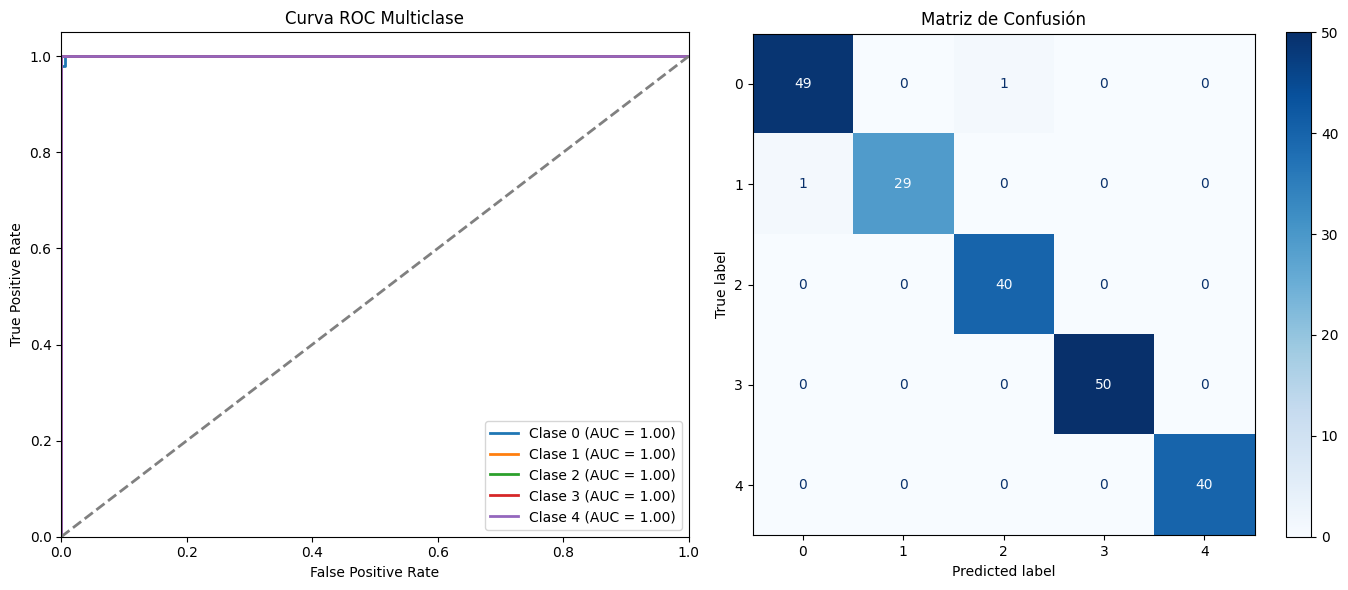

Métricas del mejor modelo en el conjunto de test:
Accuracy: 0.99048
Precision (Macro): 0.99112
Recall (Macro): 0.98933
F1 (Macro): 0.99014

Métricas del mejor modelo en el conjunto de test:
   Accuracy  Precision (Macro)  Recall (Macro)  F1 (Macro)
0   0.99048            0.99112         0.98933     0.99014


In [ ]:
# Crear la figura y los ejes para las subgráficas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # 1 fila, 2 columnas

# 1. Curva ROC
# Calcular las probabilidades de predicción
y_prob = best_model.predict_proba(X_test)  # Probabilidades de cada clase
n_classes = y_prob.shape[1]
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Inicializar las variables
fpr = dict()
tpr = dict()
roc_auc = dict()

# Calcular las curvas ROC para cada clase
for i in range(n_classes):  # n_classes es el número total de clases
    fpr[i], tpr[i], _ = roc_curve(y_test == i, y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar las curvas ROC para todas las clases
for i in range(n_classes):
    axes[0].plot(fpr[i], tpr[i], lw=2, label=f'Clase {i} (AUC = {roc_auc[i]:.2f})')

axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Línea diagonal (no discriminación)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC Multiclase')
axes[0].legend(loc='lower right')

# 2. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)

# Mostrar la matriz de confusión en el segundo eje
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues', values_format='d', ax=axes[1])  # cmap='Blues' para un buen color
axes[1].set_title('Matriz de Confusión')

# Ajustar el layout para que no se solapen las gráficas
plt.tight_layout()
plt.show()

# Calcular las métricas en el conjunto de test
accuracy = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro = recall_score(y_test, y_pred, average='macro')
f1_macro = f1_score(y_test, y_pred, average='macro')

# Mostrar las métricas
print("Métricas del mejor modelo en el conjunto de test:")
print(f"Accuracy: {accuracy:.5f}")
print(f"Precision (Macro): {precision_macro:.5f}")
print(f"Recall (Macro): {recall_macro:.5f}")
print(f"F1 (Macro): {f1_macro:.5f}")

# Crear un DataFrame con los resultados
metrics = {
    'Accuracy': [accuracy],
    'Precision (Macro)': [precision_macro],
    'Recall (Macro)': [recall_macro],
    'F1 (Macro)': [f1_macro]
}

metrics_df = pd.DataFrame(metrics)

metrics_df = metrics_df.round(5)

# Guardar los resultados en un archivo CSV
metrics_df.to_csv('model_evaluation_metrics.csv', index=False)

# Mostrar las métricas
print("\nMétricas del mejor modelo en el conjunto de test:")
print(metrics_df)

## **5. Modelo no supervisado**

###**5.1 Preprocesamiento de los datos**

#### **5.1.1 Eliminación de etiquetas**

Antes de nada, juntamos los datos en un mismo dataframe

In [7]:
#Para seccion B, sin etiquetas
df_train_B = pd.concat([dataframes_train["business"], dataframes_train["entertainment"], dataframes_train["politics"], dataframes_train["sports"], dataframes_train["tech"]], ignore_index=True)
df_test_B = pd.concat([dataframes_test["business"], dataframes_test["entertainment"], dataframes_test["politics"], dataframes_test["sports"], dataframes_test["tech"]], ignore_index=True)

In [8]:
# Aleatorizar los datos de entrenamiento y prueba
df_train_B = shuffle(df_train_B, random_state=42)
df_test_B = shuffle(df_test_B, random_state=42)

Juntamos los datos en un solo conjunto de train y test, ambos solo con texto y no con el tipo, ya que en aprendizaje supervisado no debe haber etiquetas. (Utilizamos lo que guardamos al principio)

In [9]:
X_train = df_train_B
X_test = df_test_B

#### **5.1.2 Limpiar y normalizar los textos**
Limpiamos y normalizamos los textos de la misma manera que hemos hecho para el modelo supervisado. Po ello, utilizamos la misma función que hemos creado anteriormente `preprocess_text`

In [10]:
# Inicializar lematizador y stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
def preprocess_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar signos de puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Eliminar números
    text = " ".join([word for word in text.split() if not word.isdigit()])
    # Eliminar stopwords y lematizar
    text = " ".join([lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words])
    return text
# Aplicar preprocesamiento a los textos
X_train['text'] = X_train['text'].apply(preprocess_text)
X_test['text'] = X_test['text'].apply(preprocess_text)

###**5.2 Entrenamiento del modelo principal K-Means con embedding estáticos**

En primer lugar, tokenizamos los textos en listas de palabras utilizando el método `.split()` sobre cada texto del conjunto de datos.

Después, decidimos entrenar un **embedding estático**. Exploramos distintos enfoques para realizar esta representación, como GloVe o FastText, pero finakmente elegimos **Word2Vec** debido a su eficiencia en representar relaciones semánticas de las palabras en un espacio vectorial y su capacidad para entrenarse rápidamente con grandes volúmenes de datos. Este modelo genera vectores de 100 dimensiones para cada palabra, utilizando una ventana de contexto de 5 palabras y considerando solo las palabras que aparecen al menos 2 veces en el corpus. Word2Vec convierte las palabras en vectores numéricos que capturan sus relaciones semánticas, lo que permite representar las palabras en un espacio vectorial donde palabras similares están cerca unas de otras.

La decisión de usar un embedding estático y no otras representaciones, como el modelo Bag of Words (BoW), se basó en varias razones. Los embeddings estáticos son capaces de capturar mejor las relaciones semánticas entre palabras, ya que representan cada palabra en un espacio denso y continuo, donde palabras con significados similares están cerca unas de otras. Además, a diferencia de BoW, que no tiene en cuenta las relaciones semánticas y depende únicamente de la frecuencia de las palabras, los embeddings proporcionan una representación más rica y compacta de las palabras. Esto permite que el modelo sea más efectivo al tratar con sinónimos o palabras relacionadas, algo que BoW no puede capturar adecuadamente.

Para representar cada documento como un único vector, se promedian los vectores de las palabras de cada texto. Si un documento contenía palabras que no se encontraban en el vocabulario del modelo, asignamos un vector nulo (un vector de ceros). Finalmente, convertimos todos los vectores promediados de los documentos en un array de Numpy, el cual fue utilizado para realizar el clustering posterior.

De esta manera, el uso de Word2Vec como embedding estático nos permitió obtener representaciones vectoriales semánticamente ricas para las palabras, manteniendo la simplicidad y eficiencia necesarias para el proceso de clustering.

In [11]:
# Tokenizar textos en listas de palabras
tokenized_texts = [text.split() for text in X_train['text']]

# Entrenar modelo Word2Vec
w2v_model = Word2Vec(sentences=tokenized_texts, vector_size=100, window=5, min_count=2, workers=4)

# Convertir cada documento en un vector promediando los embeddings de las palabras
X_w2v = []
for words in tokenized_texts:
    word_vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if word_vectors:  # Verificar que hay palabras en el modelo
        X_w2v.append(np.mean(word_vectors, axis=0))
    else:
        X_w2v.append(np.zeros(w2v_model.vector_size))  # Vector nulo si no hay palabras en el vocabulario

# Convertir a numpy array
X_w2v = np.array(X_w2v)

A continuación, aplicamos el **método del codo** para determinar el número óptimo de clusters a utilizar en el algoritmo K-Means.
Calculamos la **inercia (WCSS)** para diferentes valores de n_clusters (en este caso, de 1 a 15). La inercia mide la suma de las distancias cuadradas dentro de cada cluster, y su valor disminuye a medida que aumentamos el número de clusters.

Posteriormente, graficamos el WCSS en función del número de clusters para observar el punto de codo, que es el lugar donde la reducción de la inercia se vuelve más lenta. Este punto indica el número ideal de clusters para nuestro modelo, ya que agregar más clusters más allá de este punto no mejora significativamente la calidad del clustering.

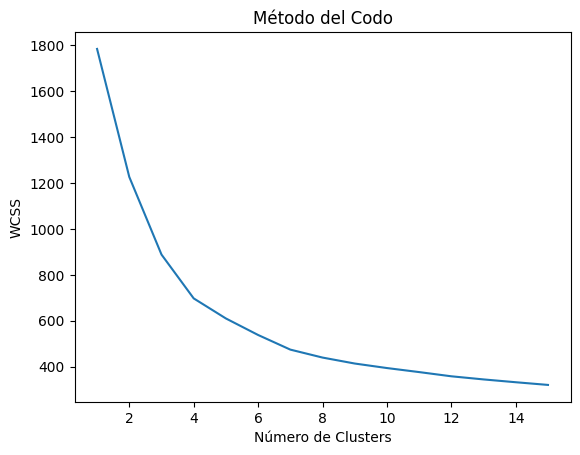

In [ ]:
# Calcular el WCSS para diferentes números de clusters
wcss = []

for i in range(1, 16):  # Probar de 1 a 10 clusters
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_w2v)  # Usamos los vectores promediados de Word2Vec
    wcss.append(kmeans.inertia_)

# Graficar el WCSS para identificar el codo
plt.plot(range(1, 16), wcss)
plt.title('Método del Codo')
plt.xlabel('Número de Clusters')
plt.ylabel('WCSS')
plt.show()

En la gráfica del método del codo, observamos que la curva de WCSS (Within-Cluster Sum of Squares) presenta una disminución pronunciada hasta aproximadamente
**k = 5, 6, 7 o 8** a partir de donde la reducción se vuelve más gradual. Esto sugiere que la ganancia en cohesión dentro de los clusters es significativa hasta estos valores, pero luego los beneficios marginales de agregar más clusters disminuyen. Dado que no tenemos un punto exacto claramente definido, decidimos construir modelos con estos cuatro valores de
𝑘 y evaluar métricas como la coherencia y el coeficiente de silueta, lo que nos permitirá seleccionar el número óptimo de clusters en función de los mejores resultados obtenidos.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
# Función para calcular la coherencia de los clústeres
def calcular_coherencia(X, clusters, top_n_words=10):
    # Crear un vectorizador para obtener las palabras más frecuentes
    vectorizer = CountVectorizer(stop_words='english', max_features=5000)
    X_vec = vectorizer.fit_transform(X)

    # Obtener las palabras más frecuentes en cada clúster
    words = np.array(vectorizer.get_feature_names_out())
    coherence_scores = []

    for cluster_id in np.unique(clusters):
        # Obtener los índices de los documentos en el clúster
        cluster_docs = np.where(clusters == cluster_id)[0]

        # Extraer los documentos del clúster
        cluster_texts = [X[i] for i in cluster_docs]

        # Crear una matriz de frecuencias de palabras en el clúster
        cluster_vec = vectorizer.transform(cluster_texts)

        # Obtener las palabras más frecuentes del clúster
        word_freq = np.asarray(cluster_vec.sum(axis=0)).flatten()
        top_word_indices = np.argsort(word_freq)[::-1][:top_n_words]
        top_words = words[top_word_indices]

        # Calcular la similitud de coseno entre las palabras más frecuentes
        top_word_vectors = [X_vec[:, idx].toarray().flatten() for idx in top_word_indices]
        similarity_matrix = cosine_similarity(top_word_vectors)

        # Promediar las similitudes de coseno (ignoramos la diagonal porque es 1)
        coherence_score = np.mean(similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)])
        coherence_scores.append(coherence_score)

    return np.mean(coherence_scores)

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Números de clusters
num_clusters_list = [5, 6, 7, 8]

# Crear una lista para almacenar los resultados
results = []

# Iterar sobre cada número de clusters
for num_clusters_optimo in num_clusters_list:
    print(f"\n\n--- Resultados para {num_clusters_optimo} clusters ---")

    # Aplicar K-Means con el número de clusters actual
    kmeans_optimo = KMeans(n_clusters=num_clusters_optimo, random_state=42, n_init=10)
    clusters = kmeans_optimo.fit_predict(X_w2v)

    # Guardar los clusters en el DataFrame
    X_train['cluster'] = clusters

    # Calcular las métricas
    silhouette = silhouette_score(X_w2v, clusters)
    dbi_score = davies_bouldin_score(X_w2v, clusters)
    ch_score = calinski_harabasz_score(X_w2v, clusters)
    coherence = calcular_coherencia(X_train['text'], clusters)

    # Redondear los resultados a 5 decimales
    silhouette = round(silhouette, 5)
    dbi_score = round(dbi_score, 5)
    ch_score = round(ch_score, 5)
    coherence = round(coherence, 5)

    # Almacenar los resultados
    results.append([num_clusters_optimo, silhouette, dbi_score, ch_score, coherence])

    # Mostrar los resultados de las métricas
    print(f"Silhouette Score: {silhouette}")
    print(f"Davies-Bouldin Index: {dbi_score}")
    print(f"Calinski-Harabasz Index: {ch_score}")
    print(f"Coherence: {coherence}")

    # Ver los resultados de los primeros 10 textos asignados a cada cluster
    print(X_train[['text', 'cluster']].head(10))

# Crear un DataFrame con los resultados
df_results = pd.DataFrame(results, columns=["Num_Clusters", "Silhouette_Score", "Davies_Bouldin_Index", "Calinski_Harabasz_Index", "Coherence"])

# Guardar el DataFrame en un archivo CSV
df_results.to_csv("metricas_clusters.csv", index=False)

# Mostrar el DataFrame
print("\nResultados guardados en 'metricas_clusters.csv':")
print(df_results)



--- Resultados para 5 clusters ---
Silhouette Score: 0.29541999101638794
Davies-Bouldin Index: 1.23654
Calinski-Harabasz Index: 967.48441
Coherence: 0.29261
                                                   text  cluster
1198  tindall want second opinion england centre mik...        4
526   redford vision sundance despite sporting cordu...        1
393   profit stall china lenovo profit chinese compu...        0
1407  prutton poised lengthy fa ban southamptons dav...        1
433   amex share spinoff news share american express...        0
1720  software watching work software monitor every ...        2
1090  mp demand budget leak answer minister asked ex...        3
429   u company admits benin bribery u defence telec...        0
1799  ultra fast wifi nears completion ultra high sp...        2
530   sir paul rock super bowl crowd sir paul mccart...        1


--- Resultados para 6 clusters ---
Silhouette Score: 0.2875100076198578
Davies-Bouldin Index: 1.24553
Calinski-Harabasz Inde

En base a los resultados obtenidos, elegimos el modelo con **5 clusters** como la mejor opción. Este modelo presenta el **mayor coeficiente de silueta** (0.2954), lo que indica que los clusters están mejor definidos y separados entre sí en comparación con los demás. Además, su índice de Davies-Bouldin (1.2365) es relativamente bajo, lo que sugiere una menor dispersión dentro de los clusters. También obtiene el mayor índice de Calinski-Harabasz (967.48), lo que indica una buena relación entre la compactación y la separación de los clusters.

Aunque el modelo con 6 clusters tiene una coherencia ligeramente mayor, su coeficiente de silueta y el índice de Calinski-Harabasz son menores, lo que sugiere que los clusters no están tan bien separados. Por otro lado, los modelos con 7 y 8 clusters muestran una disminución en la coherencia y el coeficiente de silueta, lo que indica que agregar más clusters no mejora significativamente la segmentación y puede introducir una división innecesaria.

Por estas razones, seleccionamos el modelo de 5 clusters como el más adecuado, ya que ofrece una segmentación equilibrada con una mejor separación y cohesión dentro de los grupos.

A continuación, observamos la distribución de estos clusters

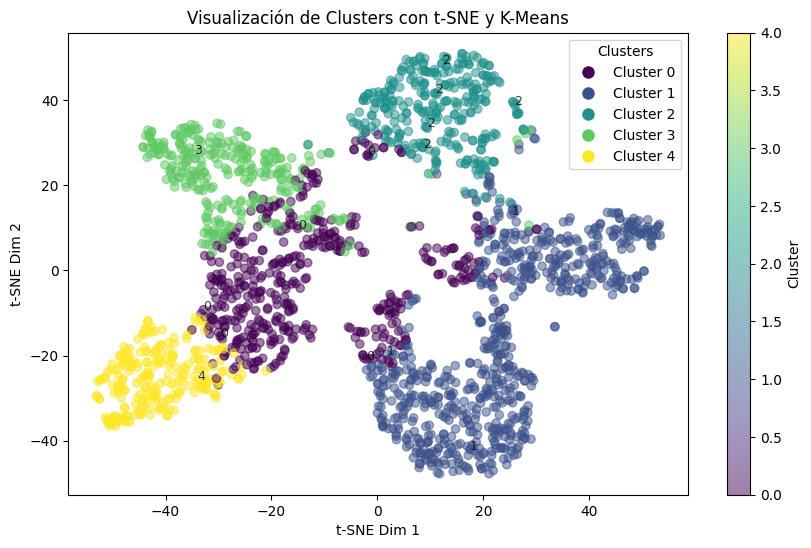

In [12]:
from sklearn.manifold import TSNE

# Número de clústeres óptimo
num_clusters_optimo = 5

# Aplicar K-Means con 5 clusters
kmeans_optimo = KMeans(n_clusters=num_clusters_optimo, random_state=42, n_init=10)
clusters = kmeans_optimo.fit_predict(X_w2v)

# Guardar los clusters en el DataFrame
X_train['cluster'] = clusters

# Reducción de dimensionalidad para la visualización con t-SNE
X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X_w2v)

# Crear scatter plot con etiquetas de cluster
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=clusters, cmap='viridis', alpha=0.5)

# Agregar una leyenda con los clusters
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(i)), markersize=10)
           for i in range(num_clusters_optimo)]
labels = [f'Cluster {i}' for i in range(num_clusters_optimo)]
plt.legend(handles, labels, title="Clusters", loc="best")

# Agregar etiquetas a algunos puntos representativos (puedes ajustar la cantidad de etiquetas mostradas)
for i in np.random.choice(range(len(X_embedded)), size=15, replace=False):  # Muestra solo 15 etiquetas aleatorias
    plt.text(X_embedded[i, 0], X_embedded[i, 1], str(clusters[i]), fontsize=9, alpha=0.75)

plt.colorbar(label="Cluster")
plt.xlabel("t-SNE Dim 1")
plt.ylabel("t-SNE Dim 2")
plt.title("Visualización de Clusters con t-SNE y K-Means")
plt.show()

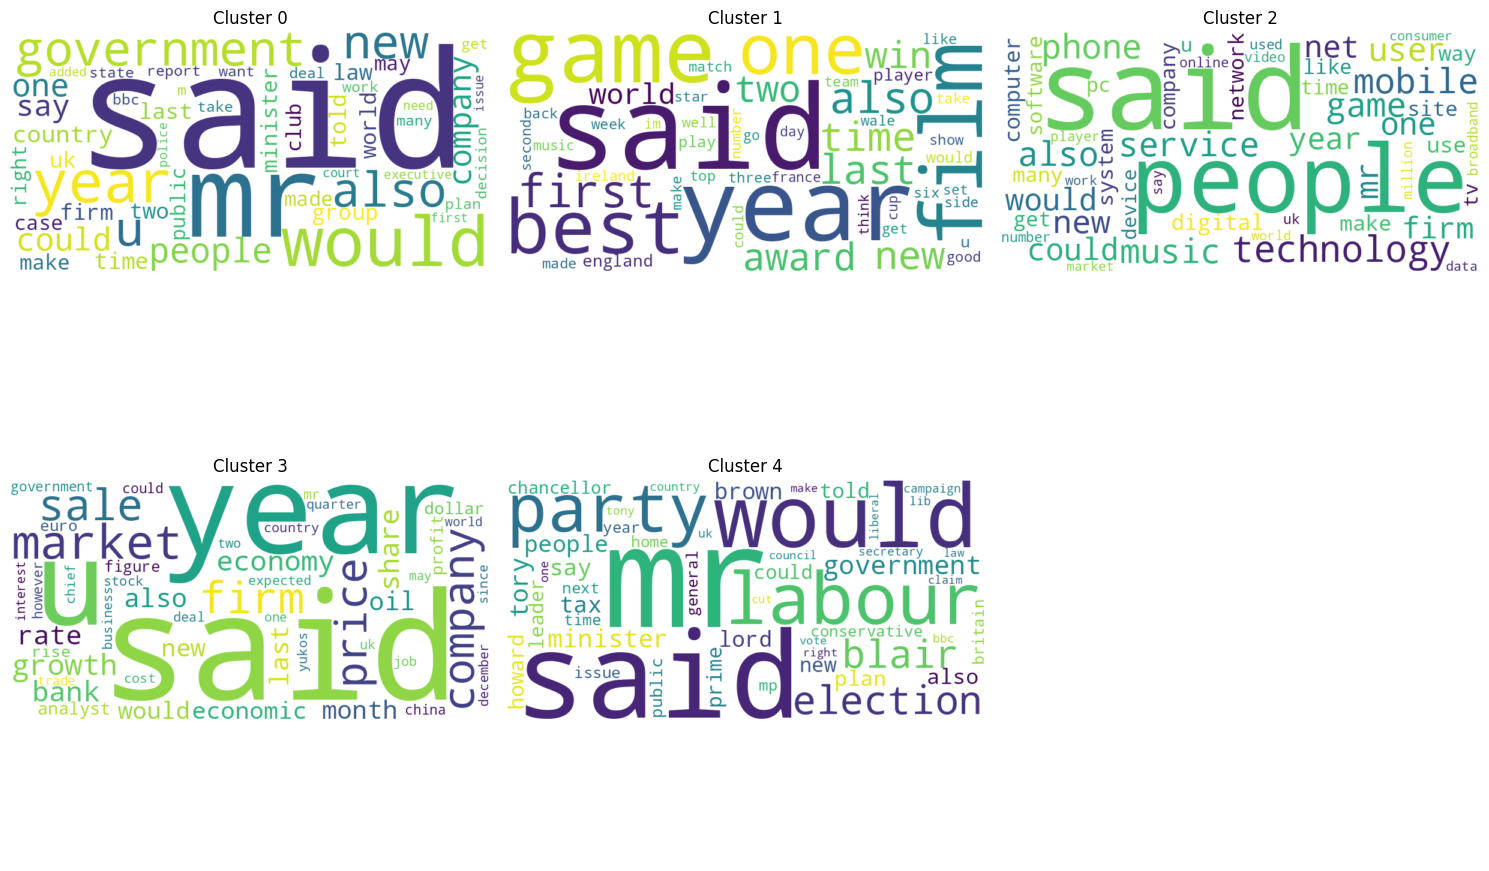

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter


# Crear una lista de palabras para cada cluster
clustered_words = {i: [] for i in range(num_clusters_optimo)}
for i, text in enumerate(X_train['text']):
    cluster_id = X_train.iloc[i]['cluster']
    clustered_words[cluster_id].extend(text.split())

# Crear subplots para las nubes de palabras (2 filas, 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Aplanar el array de ejes para facilitar la iteración
axes = axes.flatten()

# Generar una nube de palabras para cada cluster
for cluster_id, ax in enumerate(axes[:num_clusters_optimo]):  # Solo iterar sobre los clusters
    words = clustered_words[cluster_id]
    word_freq = Counter(words)
    most_common_words = dict(word_freq.most_common(50))  # Tomamos las 50 palabras más frecuentes
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(most_common_words)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(f'Cluster {cluster_id}')
    ax.axis('off')

# Eliminar cualquier subgráfico vacío (en este caso, el sexto)
for i in range(num_clusters_optimo, 6):  # Si hay más subgráficos que clusters, desactivamos los restantes
    axes[i].axis('off')

# Ajustar el layout
plt.tight_layout()
plt.show()

###**5.3 Entrenamiento de modelos adicionales**

#### **5.3.1 LDA utilizando Bag of Words**




[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Coherence Score: 0.4508


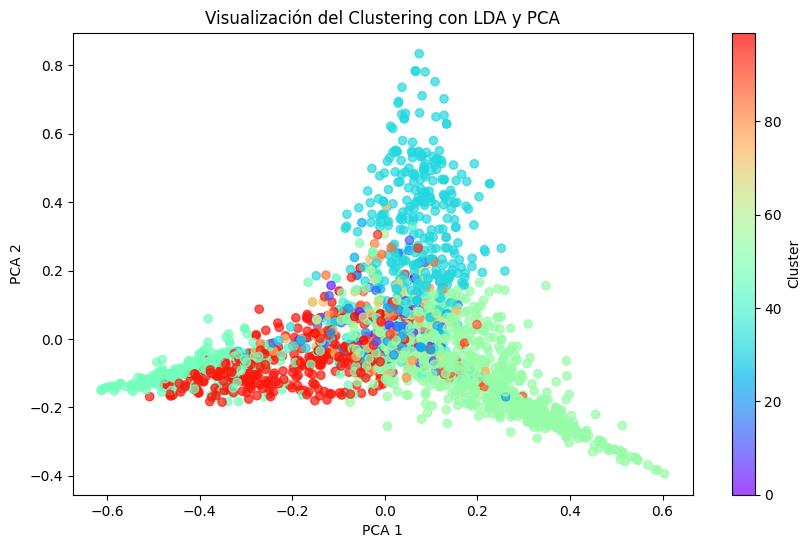

In [ ]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.decomposition import PCA

# Asegurar que las stopwords están disponibles
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Cargar datos
X_train = df_train_B.copy()
X_test = df_test_B.copy()

# Inicializar herramientas de NLP
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess_text(text):
    text = text.lower()  # Minúsculas
    text = text.translate(str.maketrans('', '', string.punctuation))  # Quitar puntuación
    tokens = word_tokenize(text)  # Tokenizar
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # Lematizar y quitar stopwords
    return tokens

# Aplicar preprocesamiento
X_train["tokens"] = X_train["text"].apply(preprocess_text)
X_test["tokens"] = X_test["text"].apply(preprocess_text)

# Crear diccionario y corpus para LDA
dictionary = Dictionary(X_train["tokens"])
corpus = [dictionary.doc2bow(text) for text in X_train["tokens"]]

# Entrenar modelo LDA
lda_model = LdaModel(corpus, id2word=dictionary, passes=10, random_state=42) #probar con mas passes (20?)

# Obtener temas asignados a cada documento
X_train_topics = [max(lda_model[doc], key=lambda x: x[1])[0] for doc in corpus]

# Evaluar coherencia del modelo
coherence_model_lda = CoherenceModel(model=lda_model, texts=X_train["tokens"], dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()
print(f"Coherence Score: {coherence_score:.4f}")

# Obtener distribuciones de tópicos para visualización
topic_distributions = np.array([lda_model.get_document_topics(doc, minimum_probability=0) for doc in corpus])
topic_matrix = np.array([[prob for _, prob in topic] for topic in topic_distributions])

# Reducir dimensiones con PCA para visualizar en 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(topic_matrix)

# Graficar los clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=X_train_topics, cmap='rainbow', alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualización del Clustering con LDA y PCA")
plt.show()


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Coherence Score: 0.4637


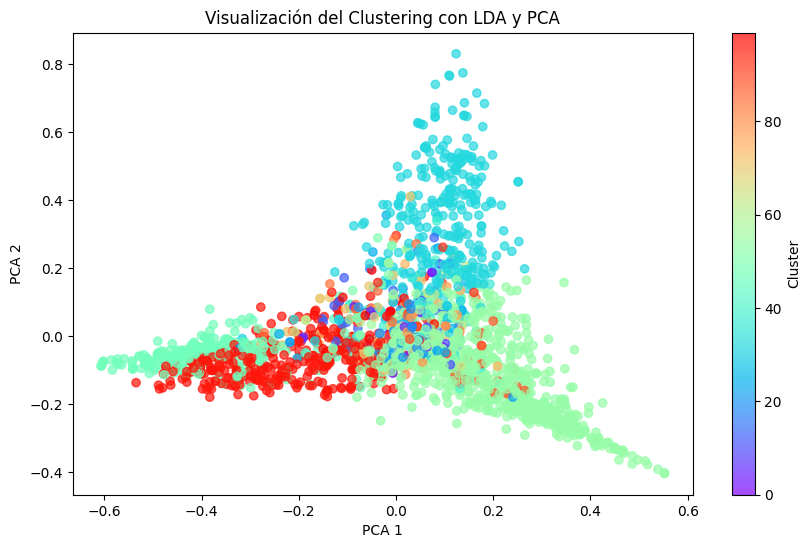

In [ ]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from sklearn.decomposition import PCA

# Asegurar que las stopwords están disponibles
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Cargar datos
X_train = df_train_B.copy()
X_test = df_test_B.copy()

# Inicializar herramientas de NLP
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess_text(text):
    text = text.lower()  # Minúsculas
    text = text.translate(str.maketrans('', '', string.punctuation))  # Quitar puntuación
    tokens = word_tokenize(text)  # Tokenizar
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # Lematizar y quitar stopwords
    return tokens

# Aplicar preprocesamiento
X_train["tokens"] = X_train["text"].apply(preprocess_text)
X_test["tokens"] = X_test["text"].apply(preprocess_text)

# Crear diccionario y corpus para LDA
dictionary = Dictionary(X_train["tokens"])
corpus = [dictionary.doc2bow(text) for text in X_train["tokens"]]

# Entrenar modelo LDA
lda_model = LdaModel(corpus, id2word=dictionary, passes=20, random_state=42) #probar con mas passes (20?)

# Obtener temas asignados a cada documento
X_train_topics = [max(lda_model[doc], key=lambda x: x[1])[0] for doc in corpus]

# Evaluar coherencia del modelo
coherence_model_lda = CoherenceModel(model=lda_model, texts=X_train["tokens"], dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model_lda.get_coherence()
print(f"Coherence Score: {coherence_score:.4f}")

# Obtener distribuciones de tópicos para visualización
topic_distributions = np.array([lda_model.get_document_topics(doc, minimum_probability=0) for doc in corpus])
topic_matrix = np.array([[prob for _, prob in topic] for topic in topic_distributions])

# Reducir dimensiones con PCA para visualizar en 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(topic_matrix)

# Graficar los clusters
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=X_train_topics, cmap='rainbow', alpha=0.7)
plt.colorbar(scatter, label="Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Visualización del Clustering con LDA y PCA")
plt.show()

#INTENTAR METER: BERT, TF-IDF!!!!!!!!!!!!!!!!
# METER UN MODELO QUE HAGA: PREPROCESAMIENTO GENERAL (PARA BERT ES MENOR), REPRESENTACION DEL TEXTO CON BERT
# Y CLUSTERING CON BERT-TOPIC (QUE USA HBDSCAN POR DEBAJO) --> 0.8~0.9

#### **5.3.2 BERTopic con embeddings contextuales**

In [ ]:
# CONCATENAR DATOS
df_train_B = pd.concat([dataframes_train["business"], dataframes_train["entertainment"], dataframes_train["politics"], dataframes_train["sports"], dataframes_train["tech"]], ignore_index=True)
df_test_B = pd.concat([dataframes_test["business"], dataframes_test["entertainment"], dataframes_test["politics"], dataframes_test["sports"], dataframes_test["tech"]], ignore_index=True)

# CARGAR DATOS EN TRAIN Y TEST
X_train = df_train_B.copy()
X_test = df_test_B.copy()


# Inicializar herramientas de NLP
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Función de preprocesamiento
def preprocess_text(text):
    text = text.lower()  # Minúsculas
    text = text.translate(str.maketrans('', '', string.punctuation))  # Quitar puntuación
    tokens = word_tokenize(text)  # Tokenizar
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # Lematizar y quitar stopwords
    return tokens

# Aplicar preprocesamiento
X_train = X_train["text"].apply(preprocess_text)
X_test = X_test["text"].apply(preprocess_text)

In [ ]:
!python -m pip install transformers bertopic sentence-transformers
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertModel
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
import matplotlib.pyplot as plt


In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Convertir los textos en embeddings usando TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Se puede ajustar
train_embeddings = vectorizer.fit_transform(X_train['text'].tolist())

# 2. Inicializar BERTopic sin embeddings contextuales
topic_model = BERTopic(
    vectorizer_model=vectorizer,  # Se usa TF-IDF
    nr_topics=20,  # Número de tópicos
    verbose=True
)

# 3. Ajustar el modelo a los documentos
topics, _ = topic_model.fit_transform(X_train['text'].tolist())

# 4. Mostrar los resultados
print(topic_model.get_topic_info().head(10))
topic_model.visualize_barchart(top_n_topics=10)


2025-03-27 16:11:15,754 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2025-03-27 16:15:11,775 - BERTopic - Embedding - Completed ✓
2025-03-27 16:15:11,776 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-27 16:15:19,915 - BERTopic - Dimensionality - Completed ✓
2025-03-27 16:15:19,916 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-27 16:15:19,987 - BERTopic - Cluster - Completed ✓
2025-03-27 16:15:19,988 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-03-27 16:15:20,433 - BERTopic - Representation - Completed ✓
2025-03-27 16:15:20,434 - BERTopic - Topic reduction - Reducing number of topics
2025-03-27 16:15:20,450 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-03-27 16:15:20,921 - BERTopic - Representation - Completed ✓
2025-03-27 16:15:20,924 - BERTopic - Topic reduction - Reduced number of topics from 35 to 20


   Topic  Count                                Name  \
0     -1    248    -1_said_patent_mobile_technology   
1      0    363        0_tory_labour_blair_election   
2      1    335        1_england_rugby_arsenal_club   
3      2    152            2_film_oscar_award_actor   
4      3    147   3_economy_economic_growth_deficit   
5      4    135             4_music_album_band_song   
6      5    117  5_roddick_seed_indoor_championship   
7      6     84        6_game_console_device_gaming   
8      7     84          7_spam_virus_security_user   
9      8     72        8_boerse_lse_ebbers_deutsche   

                                      Representation  \
0  [said, patent, mobile, technology, would, eu, ...   
1  [tory, labour, blair, election, party, mr, sai...   
2  [england, rugby, arsenal, club, chelsea, wale,...   
3  [film, oscar, award, actor, best, aviator, act...   
4  [economy, economic, growth, deficit, rate, chi...   
5  [music, album, band, song, chart, singer, arti...   
6 

In [ ]:
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from hdbscan import HDBSCAN
from umap import UMAP

# 1. Cargar modelo BERT mejorado
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')  # Modelo más robusto

# 2. Obtener embeddings para los textos
train_embeddings = model.encode(X_train['text'].tolist(), show_progress_bar=True)

# 3. Ajustar UMAP para preservar más información
umap_model = UMAP(n_neighbors=20, n_components=10, min_dist=0.2, metric='cosine')

# 4. Ajustar HDBSCAN con menor tamaño de cluster
hdbscan_model = HDBSCAN(min_cluster_size=8, metric='euclidean', cluster_selection_method='eom')

# 5. Inicializar BERTopic con ajustes mejorados
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=20,  # Se fuerza un número mayor de tópicos
    verbose=True
)

# 6. Ajustar el modelo a los embeddings de los documentos
topics, probabilities = topic_model.fit_transform(X_train['text'].tolist(), embeddings=train_embeddings)

# 7. Visualización y evaluación
print("Top 10 topics generated by BERTopic:")
print(topic_model.get_topic_info().head(10))

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.51k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2025-03-27 16:08:43,708 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-03-27 16:08:51,086 - BERTopic - Dimensionality - Completed ✓
2025-03-27 16:08:51,088 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-03-27 16:08:51,153 - BERTopic - Cluster - Completed ✓
2025-03-27 16:08:51,154 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-03-27 16:08:51,620 - BERTopic - Representation - Completed ✓
2025-03-27 16:08:51,622 - BERTopic - Topic reduction - Reducing number of topics
2025-03-27 16:08:51,633 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-03-27 16:08:52,103 - BERTopic - Representation - Completed ✓
2025-03-27 16:08:52,107 - BERTopic - Topic reduction - Reduced number of topics from 34 to 20


Top 10 topics generated by BERTopic:
   Topic  Count                             Name  \
0     -1    502            -1_said_mr_year_would   
1      0    385        0_england_game_player_win   
2      1    320          1_film_best_award_music   
3      2    232        2_mr_said_labour_election   
4      3    204  3_mobile_game_people_technology   
5      4    105      4_profit_company_share_said   
6      5     44      5_rate_dollar_price_economy   
7      6     40   6_virus_security_email_program   
8      7     29      7_yukos_russian_oil_gazprom   
9      8     24    8_network_file_p2p_bittorrent   

                                      Representation  \
0  [said, mr, year, would, new, also, company, co...   
1  [england, game, player, win, club, side, irela...   
2  [film, best, award, music, show, year, star, b...   
3  [mr, said, labour, election, blair, government...   
4  [mobile, game, people, technology, phone, said...   
5  [profit, company, share, said, firm, sale, gm,...  

Silhouette Score: 0.01981327750034341
Coherence Score: 0.6857712290493803


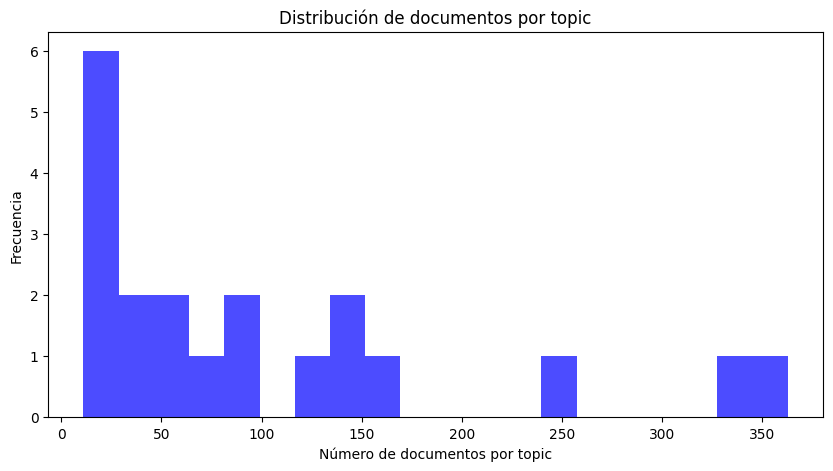

In [ ]:
from gensim.models.coherencemodel import CoherenceModel
# 1️⃣ Visualizar los topics con un barchart
topic_model.visualize_barchart(top_n_topics=10)

# 2️⃣ Mapa de clusters de los topics
topic_model.visualize_topics()

# 3️⃣ Evaluación del modelo
## 3.1. Silhouette Score (qué tan separados están los clusters)
labels = topic_model.topics_
silhouette_avg = silhouette_score(train_embeddings, labels)
print(f"Silhouette Score: {silhouette_avg}")

## 3.2. Coherencia de topics con NPMI
topics = topic_model.get_topics()
texts = X_train['text'].tolist()

from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Tokenizar los textos para que sean listas de palabras
tokenized_texts = [text.split() for text in X_train['text'].tolist()]

# Crear un diccionario de Gensim
dictionary = Dictionary(tokenized_texts)

# Obtener los topics de BERTopic y extraer solo las palabras clave
topics = topic_model.get_topics()
topics_words = [[word for word, _ in topics[i]] for i in topics if i != -1]  # Excluir -1 (outliers)

# Calcular coherencia con el diccionario
coherence_model = CoherenceModel(topics=topics_words, texts=tokenized_texts, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()

print(f"Coherence Score: {coherence_score}")

## 3.3. Distribución de documentos por topic
topic_counts = topic_model.get_topic_info()["Count"]
plt.figure(figsize=(10,5))
plt.hist(topic_counts, bins=20, color='blue', alpha=0.7)
plt.xlabel("Número de documentos por topic")
plt.ylabel("Frecuencia")
plt.title("Distribución de documentos por topic")
plt.show()

In [ ]:
# 8. Si deseas hacer predicciones sobre el conjunto de prueba:
test_topics, test_probabilities = topic_model.transform(df_test['text'], embeddings=test_embeddings)

# Ver los resultados en el conjunto de test
print("\nTopic assignments for test data:")
print(test_topics)

# Opcionalmente, si quieres hacer un análisis de la distribución de los temas:
topic_model.visualize_distribution(probabilities)

2025-03-27 15:34:45,668 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-03-27 15:34:52,961 - BERTopic - Dimensionality - Completed ✓
2025-03-27 15:34:52,963 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-03-27 15:34:52,981 - BERTopic - Cluster - Completed ✓



Topic assignments for test data:
[-1, 19, -1, -1, -1, 33, 13, -1, -1, -1, -1, 30, -1, -1, -1, 15, -1, 19, 19, 15, -1, -1, 14, -1, 33, 30, -1, -1, 24, -1, -1, -1, -1, -1, -1, -1, 33, -1, -1, -1, -1, 15, 37, 19, 15, 14, 24, -1, -1, 33, -1, 2, 2, 2, 3, -1, -1, 3, -1, 2, -1, 11, -1, -1, 2, 11, -1, 2, 2, 2, 2, 2, 2, 2, 2, -1, -1, 2, 2, 2, 27, 5, 5, -1, 6, 39, 5, 39, -1, -1, 23, 5, -1, 26, -1, -1, 6, -1, -1, -1, -1, 25, -1, -1, 5, -1, 17, -1, -1, -1, 5, -1, 5, 5, 5, -1, 26, -1, -1, -1, 7, 7, 7, 20, 9, 20, 9, 20, 20, 7, 7, 7, 7, 20, 9, 9, 20, 7, 7, 7, 7, 0, 9, 7, 7, 20, 9, 7, 7, 9, 9, 9, 9, 9, 7, 9, 9, 7, 7, 9, 9, 9, 20, 7, 7, 7, 9, 7, 7, 7, 4, 16, -1, -1, -1, -1, 11, 18, 18, 16, 4, 10, 4, -1, -1, -1, 12, -1, 18, -1, 18, 11, -1, 18, -1, 10, 10, 4, 16, 4, 10, -1, 10, 16, 16, 35, -1, 12, 11, 4]
